                                         Big Mart Sales Prediction Analysis Project

The Big Mart is a recognized and growing retail brand, which is  significant player in the valueretail and the grocery segment.  

The Big mart Sales Prediction ML Project is a very common supervvised machine learning regression problem used to predict the sales of product in different stores of Big Mart, all based on the product and the store features. 

Here, we will be using the Random Forest Regression ML Algorithm. This is becuse, this Ml algorithm uses the theory oof building many decision trees. Each tree gives a prediction and  he final output is the average of all the tree predictionss. 

In [51]:
# Importing all the libraries for the analysis  

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns 

In [52]:
# Importing the dataset 
data = pd.read_csv("Big_mart_sales.csv") 
data 

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [53]:
data.shape 

# here this is the shape of the whole data 

(8523, 12)

Now, we will be analyzing the above dataset, so that the further processing can be done, to make predictions in thr project. 

In [54]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [55]:
data.describe() 

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [56]:
data.isnull().sum()  

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

in the above code, as we can see that the Item_Weight and outlet_Size has many empty values, which need to be filled, so that ML can be applied. 

In [57]:
# Presenting all the columns in the whole data as: 
for col in data.columns:
    print(col) 

Item_Identifier
Item_Weight
Item_Fat_Content
Item_Visibility
Item_Type
Item_MRP
Outlet_Identifier
Outlet_Establishment_Year
Outlet_Size
Outlet_Location_Type
Outlet_Type
Item_Outlet_Sales


In [58]:
print(data.columns) 

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')


# Features Chosen 
The features that will be chosen are : 

1. Item_Weight 
2. Item_Fat_Content 
3. Item_Visibility 
4. item_Type  
5. Item_MRP 
6. Outlet Establishmnet Year 
7. Outlet_Size 
8. Outlet_Location_Type 
9. Outlet_Type 

# Features Explanation 
The explanation of the features will be done in the following way and hence we will see the relation, that how the features affect the sales. 

# 1.Item_Weight  
The item weightrepresents the size or the quantity of the product. Heavier items cost morw and last longer and hence they affect the sales. 

# 2.Item_Fat_Content  
Here, in the item fat content column, it represents the health preference category. Low fat content is more popular among the health conscious buyers and the regular is preferred for the buyers. Low fat milk has more sale in the urban areas. 

In [59]:
data['Item_Fat_Content'].unique()  

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

Here as we can see that this is an example of data inconsistency and the same names have to be typed. 

In [60]:
data["Item_Fat_Content"] = data["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

# 3.Item_Visibility 
It represents the shelf space given in the store. Basically, higher visibility means more attention and hence there will be more sales of that product. Hence item visibility is an important feature.  

The numbers in the item visibility column basically represent the percentage of the total display area in the shelf. Basically, it refers to the amount of the shelf space, the product gets in the store. 

# 4.Item_Type 

It represnts the category of the product. it basically represent the relation with the sales. This is becuse the different categories have different demand levels.  
For example: 

1. Snacks: the snacks have a higher demand.  
2. frozen food : the frozen food has a medium demand.
3. household items : It has a steay demand. 

In [61]:
data['Item_Type'].unique() 

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [62]:
data['Item_Type'].nunique() 
# here as we can see that there are 16 unique values  

16

# 5. Item_MRP 
This column is quite important as it represents the column of the MRP oof the product and also The MRP is important as because it affects the customer affordability. Higher sales ususlly represent the higher demand level and higher sales value. 

# 6. Outler_Establishment_year  
It represents the age of the store. Older stores have loyal customers, better reputation and trust and hence they have higher sales. 

#  7. Outlet Size 

it represents the physical size of the store. Bigger stores have higher higher number of products and hence they have usually high number of customers and hence have high footfall. 

In [63]:
data['Outlet_Size'].unique()  

# here the value nana hs to be ignored and we will be taking the high medium and small. 

array(['Medium', nan, 'High', 'Small'], dtype=object)

# 8. Outlet_Location_Type  

The outlet location type basically represents the city tier.  

Tier 1 cities have a higher income and hence people there, have a higher income and hence thay have higher spendings.  

The tier 2 and the tier 3 cities have lower incomes and hence lower spendings. 

In [64]:
data['Outlet_Location_Type'].unique() 

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

# 9. Outlet_Type 

It represents the type of store. Supermarkest have a large variety and high customer traffic. The grocery  stores have a smaller scale. hence the super markets generate the higher sales. 

In [65]:
data['Outlet_Type'].unique() 

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

Supermaket Type 3 are usually the highest sales super markets. The Type 2 markets are usually in between and the super market type 1 are those of the lowest types. 

# Filling the missing values 

Now, we wil be carrying out the missing values by usiing the fillna function to carry out the further processing.  

Item Weight and outlet size has missing values in them, whcih needs to be filled, for the pre processing. 

In [66]:
data['Item_Weight'].fillna(data['Item_Weight'].median(), inplace = True) 
data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0], inplace = True) 

data  

C:\Users\91981\AppData\Local\Temp\ipykernel_2620\1650112791.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Item_Weight'].fillna(data['Item_Weight'].median(), inplace = True)
C:\Users\91981\AppData\Local\Temp\ipykernel_2620\1650112791.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


Now, we need to remove the unnecesary columns, for the further pre processing to take place. Here, the further pre processing will take place, so as to make accurate predictions. 

In [67]:
data2 = data.drop(['Item_Identifier', 'Outlet_Identifier'], axis =  1)   
data2  

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.920,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.500,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.930,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,8.380,Regular,0.046982,Baking Goods,108.1570,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,7.210,Regular,0.145221,Snack Foods,103.1332,2009,Medium,Tier 3,Supermarket Type2,1845.5976


Now, we will be carrying out the label hot encoding, so as to convert the categorical columns into the numerical data, as the ML algorithm can only deal with numbers. 

In [68]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder()  

for col in data2.select_dtypes(include = "object").columns: 
    data2[col] = le.fit_transform(data2[col])  

data2 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300,0,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.920,1,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.500,0,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.200,1,0.000000,6,182.0950,1998,1,2,0,732.3800
4,8.930,0,0.000000,9,53.8614,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,13,214.5218,1987,0,2,1,2778.3834
8519,8.380,1,0.046982,0,108.1570,2002,1,1,1,549.2850
8520,10.600,0,0.035186,8,85.1224,2004,2,1,1,1193.1136
8521,7.210,1,0.145221,13,103.1332,2009,1,2,2,1845.5976


In [69]:
data2.isnull().sum()  
# No hidden values present 

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Now, we wiil make a short analysis to make on the categorical features and hence we will make the comparison. 

In [70]:
print(data['Item_Fat_Content'].unique()) 
print(data['Item_Type'].unique()) 
print(data['Outlet_Establishment_Year'].unique()) 
print(data['Outlet_Size'].unique()) 
print(data['Outlet_Location_Type'].unique()) 
print(data['Outlet_Type'].unique()) 

['Low Fat' 'Regular']
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']
[1999 2009 1998 1987 1985 2002 2007 1997 2004]
['Medium' 'High' 'Small']
['Tier 1' 'Tier 3' 'Tier 2']
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


In [71]:
print(data2['Item_Fat_Content'].unique()) 
print(data2['Item_Type'].unique()) 
print(data2['Outlet_Establishment_Year'].unique()) 
print(data2['Outlet_Size'].unique()) 
print(data2['Outlet_Location_Type'].unique()) 
print(data2['Outlet_Type'].unique()) 

[0 1]
[ 4 14 10  6  9  0 13  5  2  8  7  3  1 15 11 12]
[1999 2009 1998 1987 1985 2002 2007 1997 2004]
[1 0 2]
[0 2 1]
[1 2 0 3]


Now, we will be making the comparison between the actual values and the numerical encodings as:  

# 1. Item_Fat_Content 
Low Fat = 0, High Fat = 1 

# 2. Item_Type 
Dairy = 4, Soft drinks = 14, Meat = 10, Fruits and Vegetables = 6, Household = 9, Baking Goods =0, Snack Foods=13,  
Frozen Foods = 5, Breakfast = 2, Health and Hygiene = 8, Hard Drinks = 7, Canned = 3, Breads = 1, Starchy Foods = 15, 
Others  = 11, Seafood = 13 

# 3 Size 
Small = 2, Medium = 1 High = 0 

# 4.Outlet_Location_Type 
Tier1 = 0, Tier2  = 1,Tier3 =2 

# Outlet Type  
Type 1 = 1, type 2 = 2, Type 3 = 3, Grocery  = 0  

Now, we will be sepearting the models into the festures and the target labels. 

In [72]:
x =  data2.drop(['Item_Outlet_Sales'], axis = 1) 
x 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.300,0,0.016047,4,249.8092,1999,1,0,1
1,5.920,1,0.019278,14,48.2692,2009,1,2,2
2,17.500,0,0.016760,10,141.6180,1999,1,0,1
3,19.200,1,0.000000,6,182.0950,1998,1,2,0
4,8.930,0,0.000000,9,53.8614,1987,0,2,1
...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,13,214.5218,1987,0,2,1
8519,8.380,1,0.046982,0,108.1570,2002,1,1,1
8520,10.600,0,0.035186,8,85.1224,2004,2,1,1
8521,7.210,1,0.145221,13,103.1332,2009,1,2,2


In [73]:
y = data2.filter(['Item_Outlet_Sales'])
y 

,Item_Outlet_Sales
0,3735.1380
1,443.4228
2,2097.2700
3,732.3800
4,994.7052
...,...
8518,2778.3834
8519,549.2850
8520,1193.1136
8521,1845.5976


In [74]:
# Now, we will be training, testing and splitting the model uusing the train, test and split model which will take place as:   
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2) 


In [75]:
x_train # Data on which the model is trained 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
549,9.500,1,0.035206,6,171.3448,1999,1,0,1
7757,18.000,0,0.047473,9,170.5422,2002,1,1,1
764,17.600,1,0.076122,10,111.7202,1997,2,0,1
6867,8.325,0,0.029845,6,41.6138,2002,1,1,1
2716,12.850,0,0.137228,13,155.5630,1997,2,0,1
...,...,...,...,...,...,...,...,...,...
5734,9.395,1,0.286345,6,139.1838,1998,1,2,0
5191,15.600,0,0.117575,5,75.6670,2007,1,1,1
5390,17.600,0,0.018944,8,237.3590,2002,1,1,1
860,20.350,0,0.054363,13,117.9466,2007,1,1,1


In [76]:
x_test # data oon which the model is tested 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
7503,14.300,0,0.026300,5,79.4302,1987,0,2,1
2957,7.930,0,0.071136,8,42.7086,1997,2,0,1
7031,14.500,1,0.041313,3,42.0454,1999,1,0,1
1084,12.600,1,0.044767,14,173.7054,1985,1,2,3
856,10.195,1,0.012456,10,197.5110,2004,2,1,1
...,...,...,...,...,...,...,...,...,...
7205,11.800,1,0.093656,13,127.1704,1997,2,0,1
3257,7.020,0,0.000000,6,148.1734,2009,1,2,2
6346,14.500,1,0.041215,3,42.0454,1987,0,2,1
6318,9.800,1,0.141184,0,50.5008,2009,1,2,2


In [77]:
y_train # data on whcich the model is trained 

,Item_Outlet_Sales
549,2386.2272
7757,3103.9596
764,1125.2020
6867,284.2966
2716,4224.5010
...,...
5734,280.9676
5191,1301.6390
5390,6145.3340
860,1649.8524


In [78]:
y_test # data on which the model is tested 

,Item_Outlet_Sales
7503,1743.0644
2957,356.8688
7031,377.5086
1084,5778.4782
856,2356.9320
...,...
7205,3004.0896
3257,890.8404
6346,629.1810
6318,253.0040


In [79]:
# Now, we will be applying the Standard Scaler operations so, as to scale rhr whole data, and hence it would allow the easy processing 

from sklearn.preprocessing import StandardScaler  

sc = StandardScaler() 

x_train = sc.fit_transform(x_train) 
x_test = sc.transform(x_test)  

Now, come sthe main partt of traininng the Ml moodel of Random Forest Regressor to make predictions based on decision trees. 

In [80]:
from sklearn.ensemble import RandomForestRegressor 

model = RandomForestRegressor(n_estimators  = 500,  random_state = 42) 
regressor = model.fit(x_train, y_train) 
regressor 

c:\Users\91981\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
# Now, comes the making of the predictions as: 
y_pred = regressor.predict(x_test) 
y_pred 
# Predictions on the test data 

array([ 732.7688272,  907.7330776,  729.8353124, ...,  760.1878028,
        583.3819496, 1500.4282376], shape=(1705,))

## Note 
One important note, which I want to add here that in projects, we always make predictions on the test dataset, because the train datset is already been seen and hence we have to look for the test dataset. 

Now, we wwill be evaluating the metrics for the further performance of the ML Model which takes place as: 

In [82]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  

print("R2 Score: ", r2_score(y_test, y_pred)) 

print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred)) 

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred)) 

print("Root mean Squared Error: ", np.sqrt(mean_squared_error(y_test, y_pred)))   

# The r2 score comes out to be 0.565 

R2 Score:  0.5658670066550278
Mean Absolute Error:  759.091199350616
Mean Squared Error:  1179960.4808423512
Root mean Squared Error:  1086.259858800992


# Visualization 
As, we all know, that the visualizations is an important part in the data analysis projects. as it helps to understand the data better and draw better insightss. 

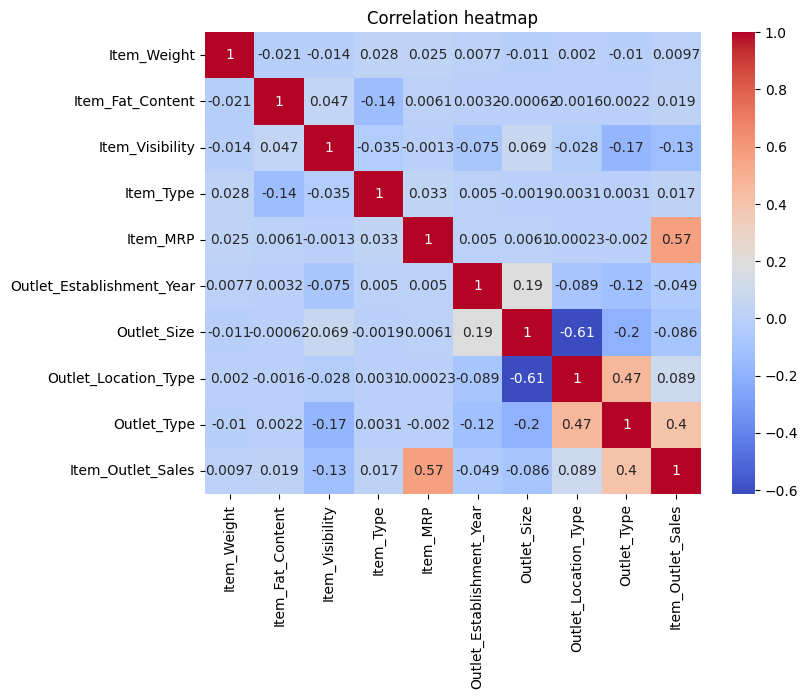

In [83]:
# First we will be plotting the correlation heatmap which will work as: 

plt.figure(figsize =(8,6)) 
sns.heatmap(data2.corr(numeric_only = True), annot = True, cmap = 'coolwarm') 
plt.title("Correlation heatmap") 
plt.show() 

This correlation heat map shows that the Item MRP and the Outlet type are the 2 most prominent factors in determining the item outlet sales. 

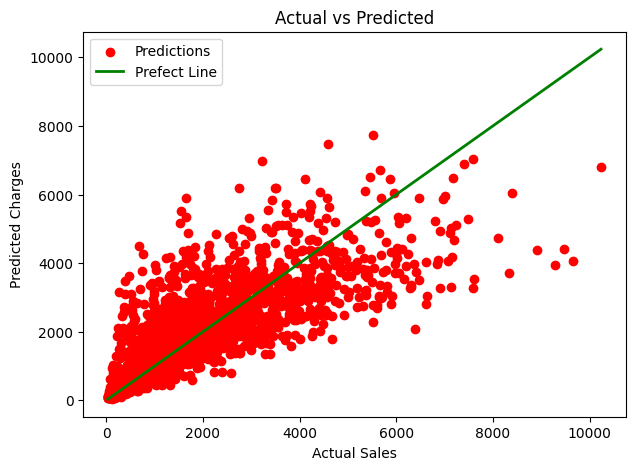

In [84]:
# Now, we will be plotting the actual vs the predicted lines for the visualization of the graph  

plt.figure(figsize = (7,5)) 
plt.scatter(y_test, y_pred, color = 'red', label = 'Predictions') 

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         color = "green", linewidth = 2, label = "Prefect Line")  

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Charges") 
plt.title("Actual vs Predicted") 
plt.legend() 
plt.show() 

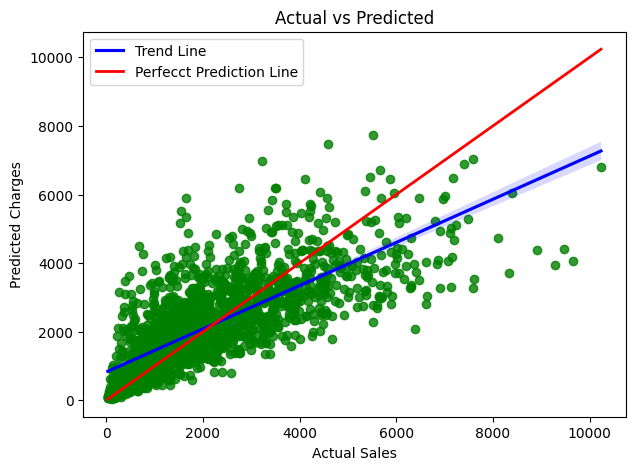

In [85]:
# Now, we plot the relation between the relation between the perfect line and the regression line of the moodel as : 

plt.figure(figsize = (7,5)) 

sns.regplot(x = y_test, y= y_pred,scatter_kws={"color": "green", "label": "Predicted Points"}, line_kws = {"color" : "blue", "label" : "Trend Line"}) 

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()], 
    color = 'red', 
    linewidth = 2,  
    label = "Perfecct Prediction Line"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Charges") 
plt.title("Actual vs Predicted") 
plt.legend() 
plt.show() 

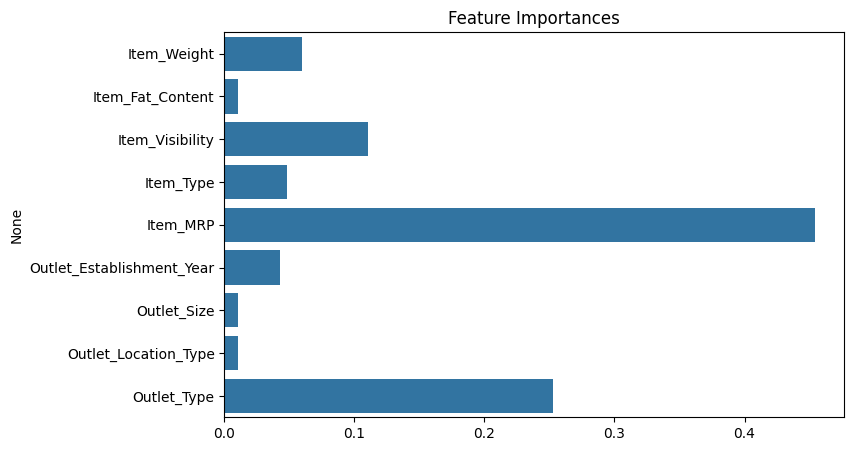

In [86]:
# Now, we will be plotting the Feature importance plot  here, to show a comparison of  the feature importances as: 

importance = regressor.feature_importances_  
features = x.columns  

plt.figure(figsize= (8,5)) 
sns.barplot(x = importance, y = features)  
plt.title("Feature Importances")
plt.show() 

Here, in the feature importance graph, we can see that the same thing which was predicted by the correlation heatmap. here, we can see that the item mrp and outlet type are the 2 most important things which are predicted.

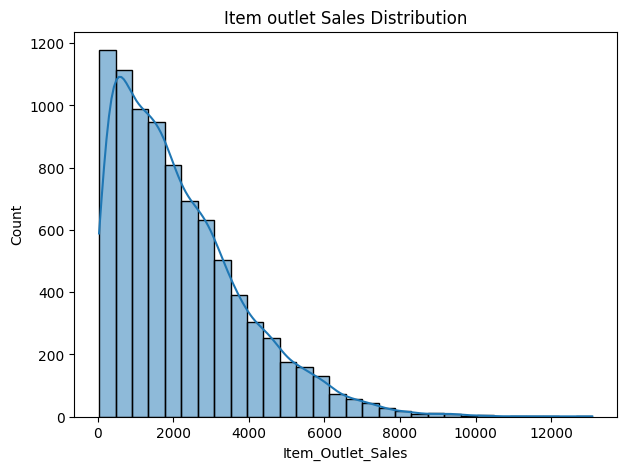

In [87]:
# now, we will be plotting the item outlet sales distribution plot as  

plt.figure(figsize = (7,5)) 
sns.histplot(data2['Item_Outlet_Sales'], kde = True, bins = 30) 
plt.title("Item outlet Sales Distribution") 
plt.show() 

Here from the distribution plot we can see that as the cost is increasing, the the count is decreasing. 

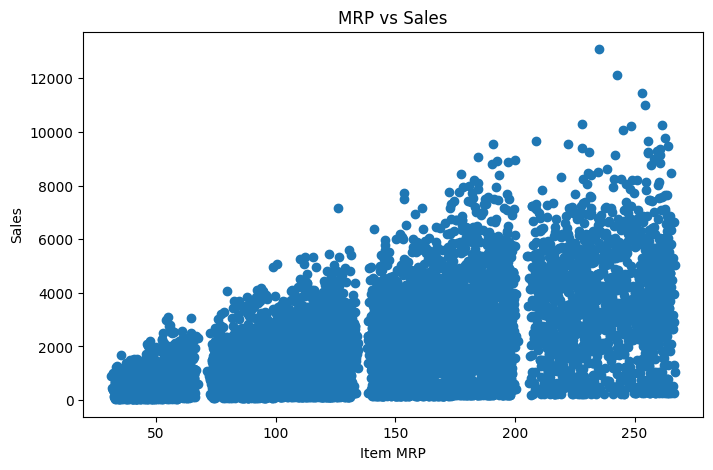

In [88]:
# Showing the scatter plot of the MP vs the sales relation as: 

plt.figure(figsize = (8,5)) 
plt.scatter(data2["Item_MRP"], data2["Item_Outlet_Sales"]) 
plt.xlabel("Item MRP") 
plt.ylabel("Sales") 
plt.title("MRP vs Sales") 
plt.show() 

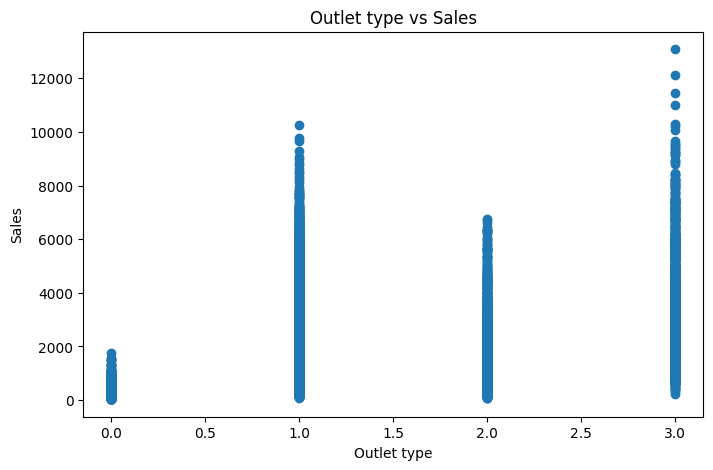

In [89]:
# Now, we will be plotting the graph for the the outlet Sales  

plt.figure(figsize = (8,5)) 
plt.scatter(data2["Outlet_Type"], data2["Item_Outlet_Sales"]) 
plt.xlabel("Outlet type") 
plt.ylabel("Sales") 
plt.title("Outlet type vs Sales") 
plt.show() 

Here this plot shows thscatter plot of the sales in the 4 types of outlet which are grocery, super market type 1, market type 2 and merket type 3. 

# Predictions 
Now,we will be making the predictions basedon the trained ML model. 

In [96]:
data2.iloc[100] 

Item_Weight                    13.300000
Item_Fat_Content                0.000000
Item_Visibility                 0.063695
Item_Type                       5.000000
Item_MRP                      151.070800
Outlet_Establishment_Year    2002.000000
Outlet_Size                     1.000000
Outlet_Location_Type            1.000000
Outlet_Type                     1.000000
Item_Outlet_Sales            1805.649600
Name: 100, dtype: float64

In [97]:
# Now, let's try making the prediction on the above dataset and hence we will be making as: 

single_record =  x.iloc[[100]]  

single_record = sc.transform(single_record) 

predicted_outcome = regressor.predict(single_record) 

print(predicted_outcome) 

[2726.51758]


# Making the predictions on the new dataset 

In [105]:
new_customer1 = pd.DataFrame({
    "Item_Weight": [9.67],
    "Item_Fat_Content": ["Low Fat"],
    "Item_Visibility": [0.15],
    "Item_Type": ["Snack Foods"],
    "Item_MRP": [67.98],
    "Outlet_Establishment_Year": [1999],
    "Outlet_Size" : ["Medium"],
    "Outlet_Location_Type" : ["Tier 1"],
    "Outlet_Type" : ["Supermarket Type1"] 
})  
new_customer1 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.67,Low Fat,0.15,Snack Foods,67.98,1999,Medium,Tier 1,Supermarket Type1


In [106]:
le = LabelEncoder()  

for col in new_customer1.select_dtypes(include = "object").columns: 
    new_customer1[col] = le.fit_transform(new_customer1[col])   

new_customer1 


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.67,0,0.15,0,67.98,1999,0,0,0


In [107]:
new_customer1 = sc.transform(new_customer1) 

prediction =  regressor.predict(new_customer1)  

print("The predicted cost is: ", prediction[0]) 

The predicted cost is:  199.6787464000001


In [111]:
new_customer2 = pd.DataFrame({
    "Item_Weight": [11.87],
    "Item_Fat_Content": ["Regular"],
    "Item_Visibility": [0.35],
    "Item_Type": ["Meat"],
    "Item_MRP": [134.7],
    "Outlet_Establishment_Year": [1987],
    "Outlet_Size" : ["High"],
    "Outlet_Location_Type" : ["Tier 3"],
    "Outlet_Type" : ["Supermarket Type3"] 
})  
new_customer2 

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,11.87,Regular,0.35,Meat,134.7,1987,High,Tier 3,Supermarket Type3


In [112]:
le = LabelEncoder()  

for col in new_customer2.select_dtypes(include = "object").columns: 
    new_customer2[col] = le.fit_transform(new_customer2[col])   

new_customer2 


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,11.87,0,0.35,0,134.7,1987,0,0,0


In [113]:
new_customer2 = sc.transform(new_customer2) 

prediction =  regressor.predict(new_customer2)  

print("The predicted cost is: ", prediction[0]) 

The predicted cost is:  541.9132624000006


Hence, the predictions on the above data have been made by the training model. 